In [3]:
import pandas as pd
from functools import reduce
import os

# 1. Define your file list (Make sure names match exactly what you uploaded)
my_stocks = ['M_IN.csv', 'D_EN.csv', 'E_EN.csv', 'H_EN.csv', 'Ab_EN.csv']

def colab_data_engine(file_list):
    processed_dfs = []

    for file in file_list:
        if not os.path.exists(file):
            print(f"❌ File not found: {file}")
            continue

        df = pd.read_csv(file)
        stock_name = file.replace('.csv', '')

        # Standardize headers (Handling the different formats in your files)
        df.columns = [c.strip().upper().replace('"', '') for c in df.columns]
        df = df.rename(columns={'PRICE': 'CLOSE', 'LTP': 'CLOSE'})

        # Standardize Dates
        df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True, errors='coerce')

        # Clean Numeric Commas (e.g., "1,200" -> 1200)
        if df['CLOSE'].dtype == 'object':
            df['CLOSE'] = df['CLOSE'].str.replace(',', '').astype(float)

        df = df[['DATE', 'CLOSE']].dropna().rename(columns={'CLOSE': stock_name})
        processed_dfs.append(df)
        print(f"✅ Loaded {stock_name}")

    # Merge all dataframes on 'DATE'
    master_df = reduce(lambda left, right: pd.merge(left, right, on='DATE', how='outer'), processed_dfs)

    # Sort and Forward Fill (Handle holidays)
    master_df = master_df.sort_values('DATE').fillna(method='ffill')

    # Filter: Only keep rows where EVERY stock has data (Synchronized start)
    master_df = master_df.dropna()

    return master_df

# Run the engine
portfolio_data = colab_data_engine(my_stocks)
portfolio_data.to_csv('Master_Portfolio.csv', index=False)
print("\n--- Portfolio Sync Complete ---")
print(portfolio_data.head())

✅ Loaded M_IN
✅ Loaded D_EN
✅ Loaded E_EN
✅ Loaded H_EN
✅ Loaded Ab_EN

--- Portfolio Sync Complete ---
          DATE   M_IN   D_EN    E_EN    H_EN   Ab_EN
275 2019-04-12  19.75  10.64  240.80  135.95  118.92
276 2019-04-15  23.65  10.92  250.00  136.75  118.02
277 2019-04-16  25.60  10.87  251.60  137.55  117.20
278 2019-04-18  26.15  10.83  251.45  135.35  117.32
279 2019-04-22  24.60  10.17  252.05  136.00  114.95


/tmp/ipykernel_1022/2200899332.py:38: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_df = master_df.sort_values('DATE').fillna(method='ffill')


In [4]:
import numpy as np

# We will apply the logic to each stock in our merged portfolio
stocks = [c for c in portfolio_data.columns if c != 'DATE']
signal_data = portfolio_data.copy()

for stock in stocks:
    # A. Calculate Indicators
    signal_data[f'{stock}_SMA21'] = signal_data[stock].rolling(window=21).mean()
    signal_data[f'{stock}_SMA50'] = signal_data[stock].rolling(window=50).mean()
    signal_data[f'{stock}_SMA200'] = signal_data[stock].rolling(window=200).mean()

    # B. Define Regime (Bullish Filter)
    # 1 if Price > SMA200
    signal_data[f'{stock}_Regime'] = np.where(signal_data[stock] > signal_data[f'{stock}_SMA200'], 1, 0)

    # C. Define Trend (Crossover Filter)
    # 1 if SMA21 > SMA50
    signal_data[f'{stock}_Trend'] = np.where(signal_data[f'{stock}_SMA21'] > signal_data[f'{stock}_SMA50'], 1, 0)

    # D. Define Entry Signal
    # Entry = Current Trend is 1, Previous Trend was 0, and Regime is 1
    signal_data[f'{stock}_Buy'] = np.where(
        (signal_data[f'{stock}_Trend'] == 1) &
        (signal_data[f'{stock}_Trend'].shift(1) == 0) &
        (signal_data[f'{stock}_Regime'] == 1), 1, 0)

    # E. Define Exit Signal
    # Exit = Current Trend is 0, Previous Trend was 1 (SMA21 crosses below SMA50)
    signal_data[f'{stock}_Exit'] = np.where(
        (signal_data[f'{stock}_Trend'] == 0) &
        (signal_data[f'{stock}_Trend'].shift(1) == 1), 1, 0)

print("✅ Signals generated for all stocks.")
# Let's see how many buy signals were triggered for each stock
for stock in stocks:
    print(f"{stock} Buy Signals: {signal_data[f'{stock}_Buy'].sum()}")

✅ Signals generated for all stocks.
M_IN Buy Signals: 10
D_EN Buy Signals: 8
E_EN Buy Signals: 13
H_EN Buy Signals: 12
Ab_EN Buy Signals: 8


In [5]:
# 1. Initialize Portfolio Results
portfolio_metrics = []

for stock in stocks:
    # A. Calculate Position (1 = Holding, 0 = Cash)
    # If Buy == 1, we enter. If Exit == 1, we leave.
    signal_data[f'{stock}_Position'] = 0
    curr_pos = 0
    positions = []

    for i in range(len(signal_data)):
        if signal_data.iloc[i][f'{stock}_Buy'] == 1:
            curr_pos = 1
        elif signal_data.iloc[i][f'{stock}_Exit'] == 1:
            curr_pos = 0
        positions.append(curr_pos)

    signal_data[f'{stock}_Position'] = positions

    # B. Calculate Strategy Returns
    # Daily % change of the stock * whether we were holding it yesterday
    signal_data[f'{stock}_Daily_Ret'] = signal_data[stock].pct_change()
    signal_data[f'{stock}_Strategy_Ret'] = signal_data[f'{stock}_Position'].shift(1) * signal_data[f'{stock}_Daily_Ret']

    # C. Calculate Equity Curve (Growth of 1 unit of currency)
    signal_data[f'{stock}_Equity'] = (1 + signal_data[f'{stock}_Strategy_Ret'].fillna(0)).cumprod()

    # D. Calculate Max Drawdown (The Peak-to-Trough drop)
    rolling_max = signal_data[f'{stock}_Equity'].cummax()
    drawdown = (signal_data[f'{stock}_Equity'] - rolling_max) / rolling_max
    max_dd = drawdown.min() * 100

    # E. Calculate Total Return & Sharpe Ratio (Annualized)
    total_ret = (signal_data[f'{stock}_Equity'].iloc[-1] - 1) * 100
    std_dev = signal_data[f'{stock}_Strategy_Ret'].std() * np.sqrt(252)
    sharpe = (signal_data[f'{stock}_Strategy_Ret'].mean() * 252) / std_dev if std_dev != 0 else 0

    portfolio_metrics.append({
        'Stock': stock,
        'Total Return (%)': round(total_ret, 2),
        'Max Drawdown (%)': round(max_dd, 2),
        'Sharpe Ratio': round(sharpe, 2)
    })

# Display the Professional Analytics Table
metrics_df = pd.DataFrame(portfolio_metrics).sort_values(by='Sharpe Ratio', ascending=False)
print("--- Final Strategy Performance Analytics ---")
print(metrics_df.to_string(index=False))

--- Final Strategy Performance Analytics ---
Stock  Total Return (%)  Max Drawdown (%)  Sharpe Ratio
 D_EN           1208.08            -41.94          1.23
 M_IN            566.59            -37.32          0.97
 E_EN            124.38            -27.83          0.67
 H_EN            109.88            -26.48          0.67
Ab_EN             95.61            -19.89          0.61


/tmp/ipykernel_1022/2995471012.py:30: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


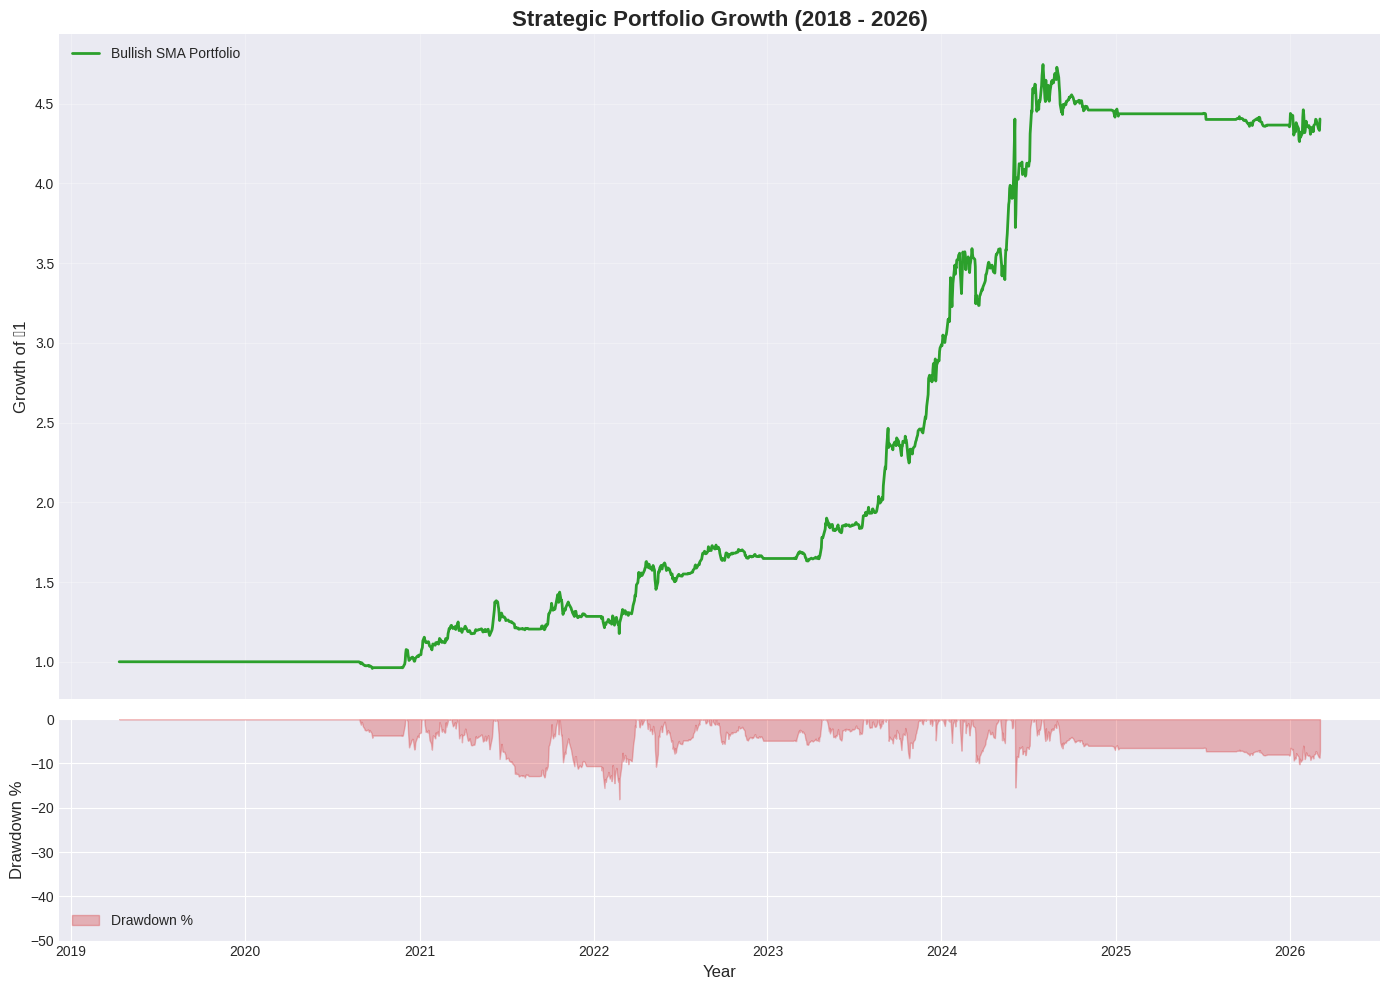

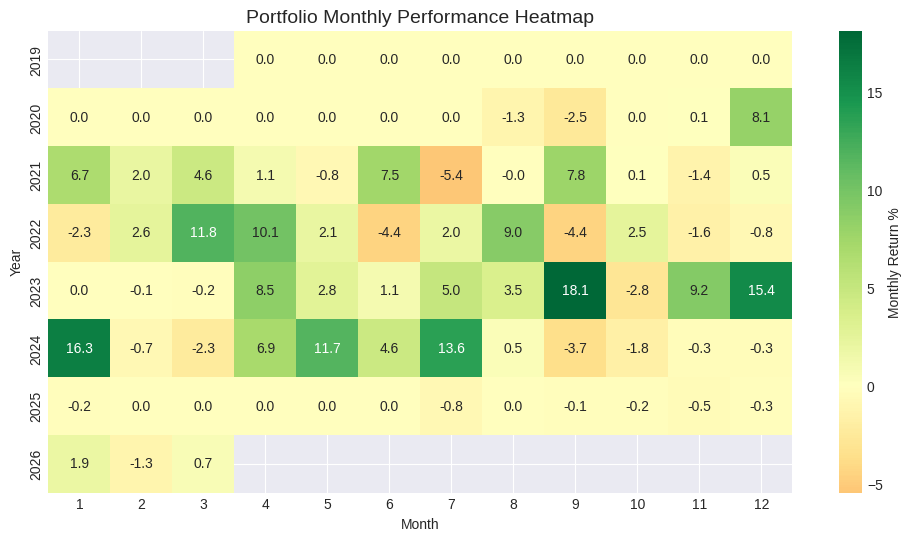

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a Combined Portfolio Equity Curve
# We assume equal allocation (20% to each of the 5 stocks)
strategy_columns = [f'{stock}_Strategy_Ret' for stock in stocks]
signal_data['Portfolio_Ret'] = signal_data[strategy_columns].mean(axis=1)
signal_data['Portfolio_Equity'] = (1 + signal_data['Portfolio_Ret'].fillna(0)).cumprod()

# 2. Professional Plotting
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Cumulative Returns
ax1.plot(signal_data['DATE'], signal_data['Portfolio_Equity'], label='Bullish SMA Portfolio', color='#2ca02c', lw=2)
ax1.set_title('Strategic Portfolio Growth (2018 - 2026)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Growth of ₹1', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Drawdown (The "Pain" Chart)
rolling_max = signal_data['Portfolio_Equity'].cummax()
drawdown = (signal_data['Portfolio_Equity'] - rolling_max) / rolling_max
ax2.fill_between(signal_data['DATE'], drawdown * 100, 0, color='#d62728', alpha=0.3, label='Drawdown %')
ax2.set_ylabel('Drawdown %', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylim(-50, 0)
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

# 3. Monthly Heatmap (The "Executive" View)
signal_data['Year'] = signal_data['DATE'].dt.year
signal_data['Month'] = signal_data['DATE'].dt.month
monthly_ret = signal_data.groupby(['Year', 'Month'])['Portfolio_Ret'].sum().unstack() * 100

plt.figure(figsize=(12, 6))
sns.heatmap(monthly_ret, annot=True, fmt=".1f", cmap='RdYlGn', center=0, cbar_kws={'label': 'Monthly Return %'})
plt.title('Portfolio Monthly Performance Heatmap', fontsize=14)
plt.show()